# 🚀 Space Missions Analysis (1957–2020)

Analyse van **4.324 ruimtemissies** over 63 jaar — van de eerste Spoetnik tot SpaceX.

**Dataset:** [nextspaceflight.com](https://nextspaceflight.com/launches/past/)  
**Kolommen:** Organisatie, Locatie, Datum, Raket, Rocket_Status, Prijs (M$), Mission_Status

---
**Vragen die we beantwoorden:**
1. Wie lanceerde de meeste missies per jaar?
2. Hoe zijn de kosten veranderd door de jaren heen?
3. In welke maanden vinden de meeste lanceringen plaats?
4. Zijn ruimtemissies veiliger geworden?
5. Welke organisaties hebben de beste succesratio?
6. Actieve vs gepensioneerde raketten per organisatie


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ── Stijl ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#0d1117',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':     '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':      '#21262d',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,        'axes.titleweight': 'bold',
})
ACCENT  = '#58a6ff'   # blauw
ACCENT2 = '#f78166'   # rood/oranje
ACCENT3 = '#3fb950'   # groen
ACCENT4 = '#d29922'   # goud


In [ ]:
# ── Data laden ───────────────────────────────────────────────
df = pd.read_csv('mission_launches.csv', index_col=0)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# ── Datum parsen ─────────────────────────────────────────────
df['Date']  = pd.to_datetime(
    df['Date'], format='%a %b %d, %Y %H:%M UTC', errors='coerce')
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# ── Prijs opschonen (verwijder komma's, converteer naar float) ──
df['Price'] = pd.to_numeric(
    df['Price'].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# ── Land extraheren uit Location ─────────────────────────────
df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())
country_map = {
    'USA': 'United States', 'Russia': 'Russia', 'Kazakhstan': 'Russia',
    'China': 'China', 'France': 'France', 'Japan': 'Japan',
    'India': 'India', 'Iran': 'Iran', 'Israel': 'Israel',
    'New Zealand': 'New Zealand', 'Marshall Islands': 'United States',
}
df['Country'] = df['Country'].map(country_map).fillna(df['Country'])

# ── Afgeleide kolommen ───────────────────────────────────────
df['Success'] = df['Mission_Status'] == 'Success'
df['Decade']  = (df['Year'] // 10 * 10).astype('Int64').astype(str) + 's'

print(f"✅ Dataset geladen: {len(df):,} missies | {df['Year'].min():.0f}–{df['Year'].max():.0f}")
print(f"   Prijs beschikbaar: {df['Price'].notna().sum()} missies ({df['Price'].notna().mean()*100:.1f}%)")
print(f"   Algemeen slagingspercentage: {df['Success'].mean()*100:.1f}%")
print(f"\nTop 5 organisaties:")
print(df['Organisation'].value_counts().head().to_string())


## 1. 🌍 Wie lanceerde de meeste missies per jaar?

De Sovjet-Unie domineerde de ruimterace in de jaren 60–80. De VS piekte rond Apollo. China groeit exponentieel na 2000.

In [ ]:
# Missies per jaar per land
yearly_country = (df.groupby(['Year', 'Country'])
                    .size().reset_index(name='Launches'))
top_countries = ['United States', 'Russia', 'China', 'France', 'India']
data_top = yearly_country[yearly_country['Country'].isin(top_countries)]
colors = [ACCENT, ACCENT2, ACCENT3, ACCENT4, '#bc8cff']

fig, ax = plt.subplots(figsize=(14, 6))
for i, country in enumerate(top_countries):
    d = data_top[data_top['Country'] == country]
    ax.plot(d['Year'], d['Launches'], label=country,
            color=colors[i], linewidth=2, alpha=0.9)
    ax.fill_between(d['Year'], d['Launches'], alpha=0.07, color=colors[i])

ax.axvline(1969, color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.4)
ax.text(1970, 110, 'Apollo 11\n(1969)', color='#ffffff', alpha=0.5, fontsize=8)
ax.set_title('🚀 Ruimtelanceringen per jaar per land (1957–2020)', pad=15)
ax.set_xlabel('Jaar'); ax.set_ylabel('Aantal lanceringen')
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

piek = df[df['Country']=='Russia'].groupby('Year').size()
print(f"Piekjaar Rusland: {piek.idxmax():.0f} ({piek.max()} lanceringen)")
print(f"Piekjaar VS: ", df[df['Country']=='United States'].groupby('Year').size().idxmax())


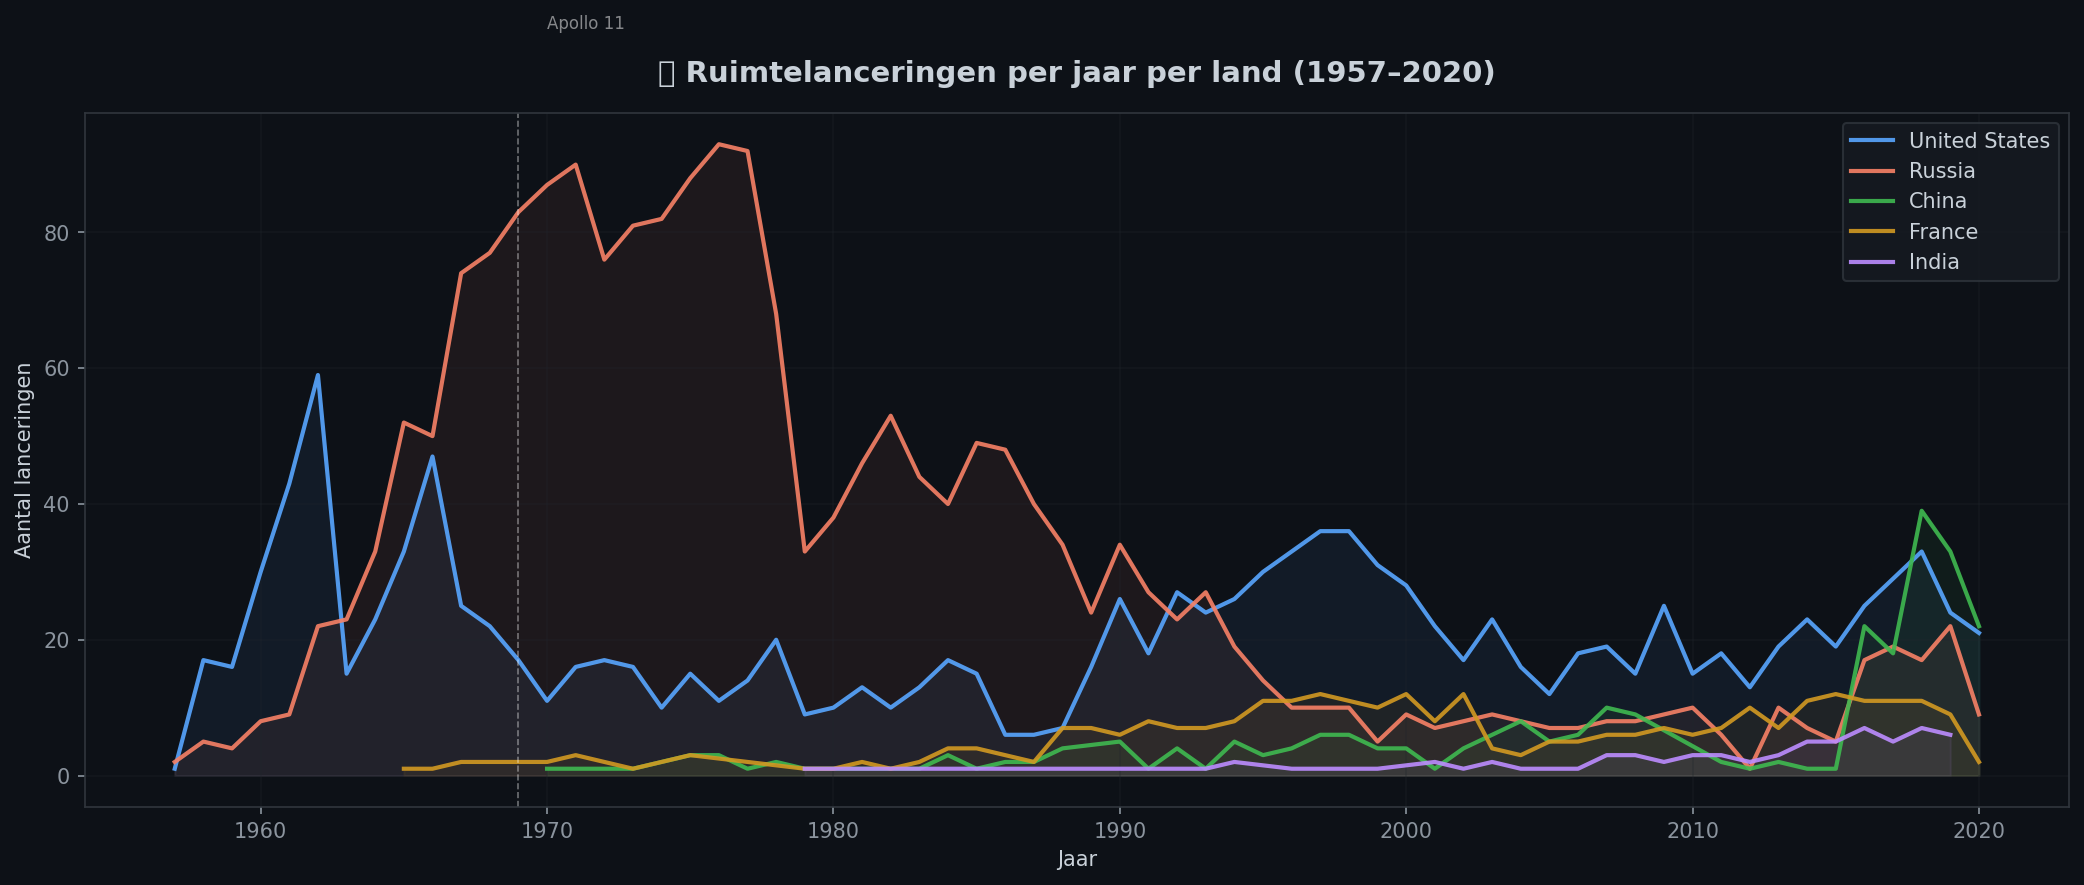

## 2. 💰 Hoe zijn de kosten veranderd?

Prijzen in miljoenen USD. Slechts 22% van de missies heeft een bekende prijs. De mediaan is robuuster dan het gemiddelde bij extreme uitschieters (Saturn V: $185M in de jaren 60).

In [ ]:
price_df = df.dropna(subset=['Price'])
yearly_price = (price_df.groupby('Year')['Price']
                .agg(['median', 'count']).reset_index())
yearly_price.columns = ['Year', 'Median', 'Count']

fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [3, 1]})
ax = axes[0]
ax.plot(yearly_price['Year'], yearly_price['Median'],
        color=ACCENT, linewidth=2.5, label='Mediaanprijs')
ax.fill_between(yearly_price['Year'], yearly_price['Median'],
                alpha=0.15, color=ACCENT)
ax.scatter(yearly_price['Year'], yearly_price['Median'],
           color=ACCENT, s=40, zorder=6, alpha=0.8)
ax.set_title('💰 Kosten van ruimtemissies: mediaan per jaar (M USD)', pad=15)
ax.set_ylabel('Prijs (M USD, log-schaal)'); ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')

axes[1].bar(yearly_price['Year'], yearly_price['Count'],
            color=ACCENT3, alpha=0.7, width=0.8)
axes[1].set_ylabel('Missies met\nbekende prijs')
axes[1].set_xlabel('Jaar'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Duurste missie: {price_df.nlargest(1,'Price').iloc[0]['Detail'][:60]}")
print(f"Prijs: ${price_df['Price'].max():,.0f}M")
print(f"\nGoedkoopste missie: {price_df.nsmallest(1,'Price').iloc[0]['Detail'][:60]}")
print(f"Prijs: ${price_df['Price'].min():,.1f}M")


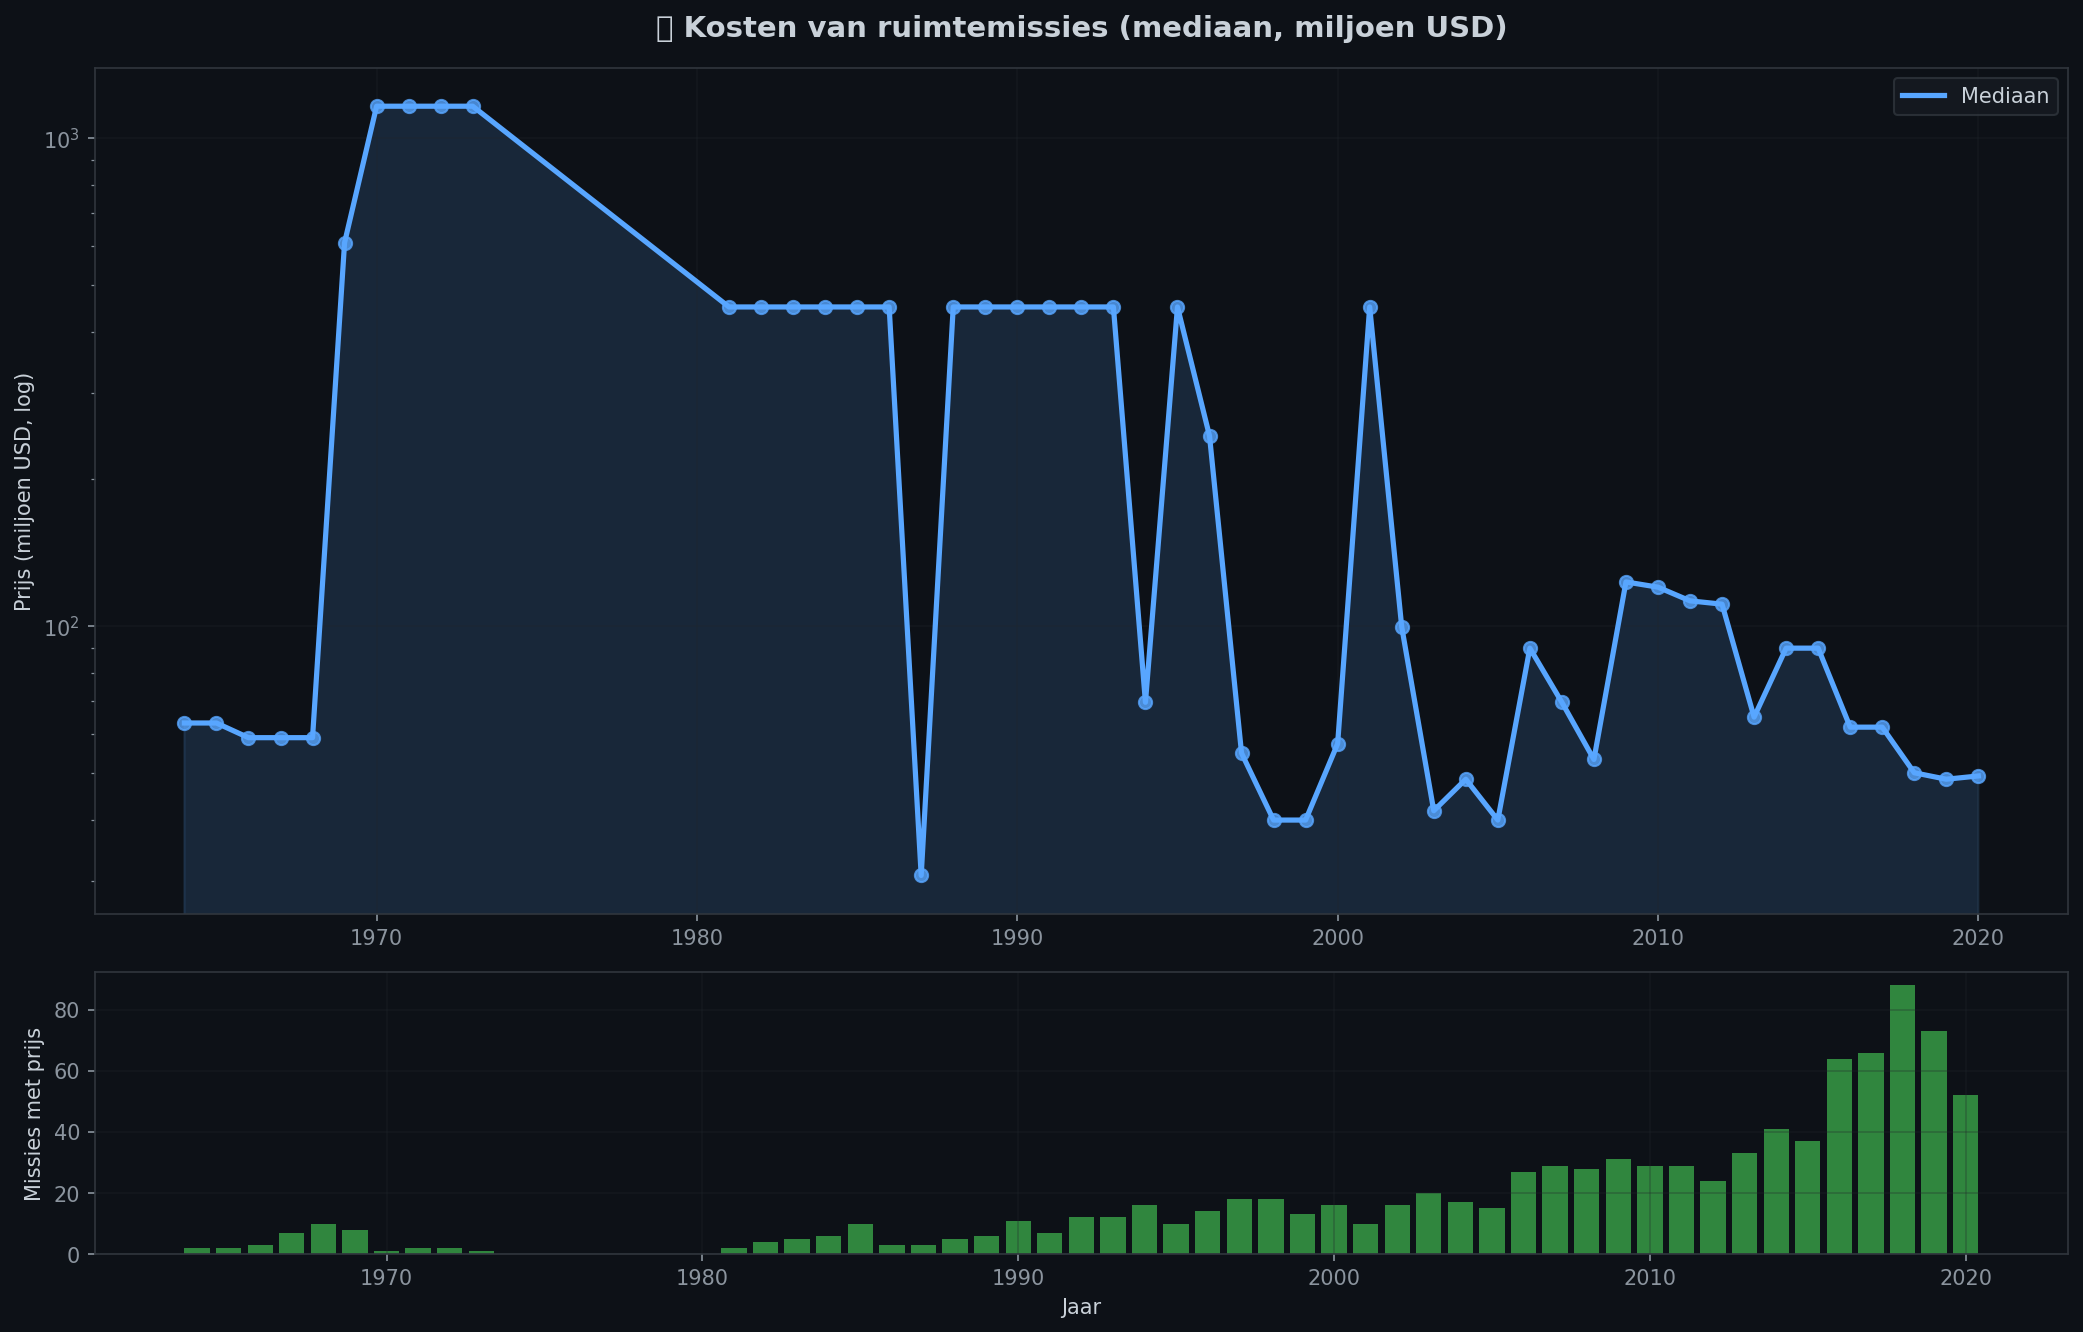

## 3. 📅 In welke maanden vinden de meeste lanceringen plaats?

December en januari zijn relatief rustig. De zomer- en herfstmaanden zijn drukker — deels door gunstige baancondities en politieke factoren (begrotingsjaar VS).

In [ ]:
MO = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month').size().reset_index(name='Count')
heatmap_data = df.groupby(['Decade','Month']).size().unstack(fill_value=0)
heatmap_data.columns = [MO[int(m)-1] for m in heatmap_data.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.bar(range(1, 13), monthly['Count'],
        color=[ACCENT if v > monthly['Count'].mean() else '#30363d'
               for v in monthly['Count']],
        edgecolor='#21262d', linewidth=0.5)
ax1.set_xticks(range(1, 13)); ax1.set_xticklabels(MO)
ax1.axhline(monthly['Count'].mean(), color=ACCENT2, linewidth=1.5,
            linestyle='--', label=f"Gem. ({monthly['Count'].mean():.0f})")
ax1.set_title('Lanceringen per maand (totaal)')
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax1.grid(True, alpha=0.3, axis='y')

avail = [m for m in MO if m in heatmap_data.columns]
sns.heatmap(heatmap_data[avail], ax=ax2, cmap='YlOrRd',
            linewidths=0.5, linecolor='#0d1117',
            annot=True, fmt='d', annot_kws={'size': 8})
ax2.set_title('Lanceringen per maand × decennium')
plt.suptitle('📅 Seizoensgebondenheid van ruimtelanceringen', y=1.02)
plt.tight_layout(); plt.show()

print("Drukste maand:", MO[monthly['Count'].idxmax()],
      f"({monthly['Count'].max()} lanceringen)")
print("Rustigste maand:", MO[monthly['Count'].idxmin()],
      f"({monthly['Count'].min()} lanceringen)")


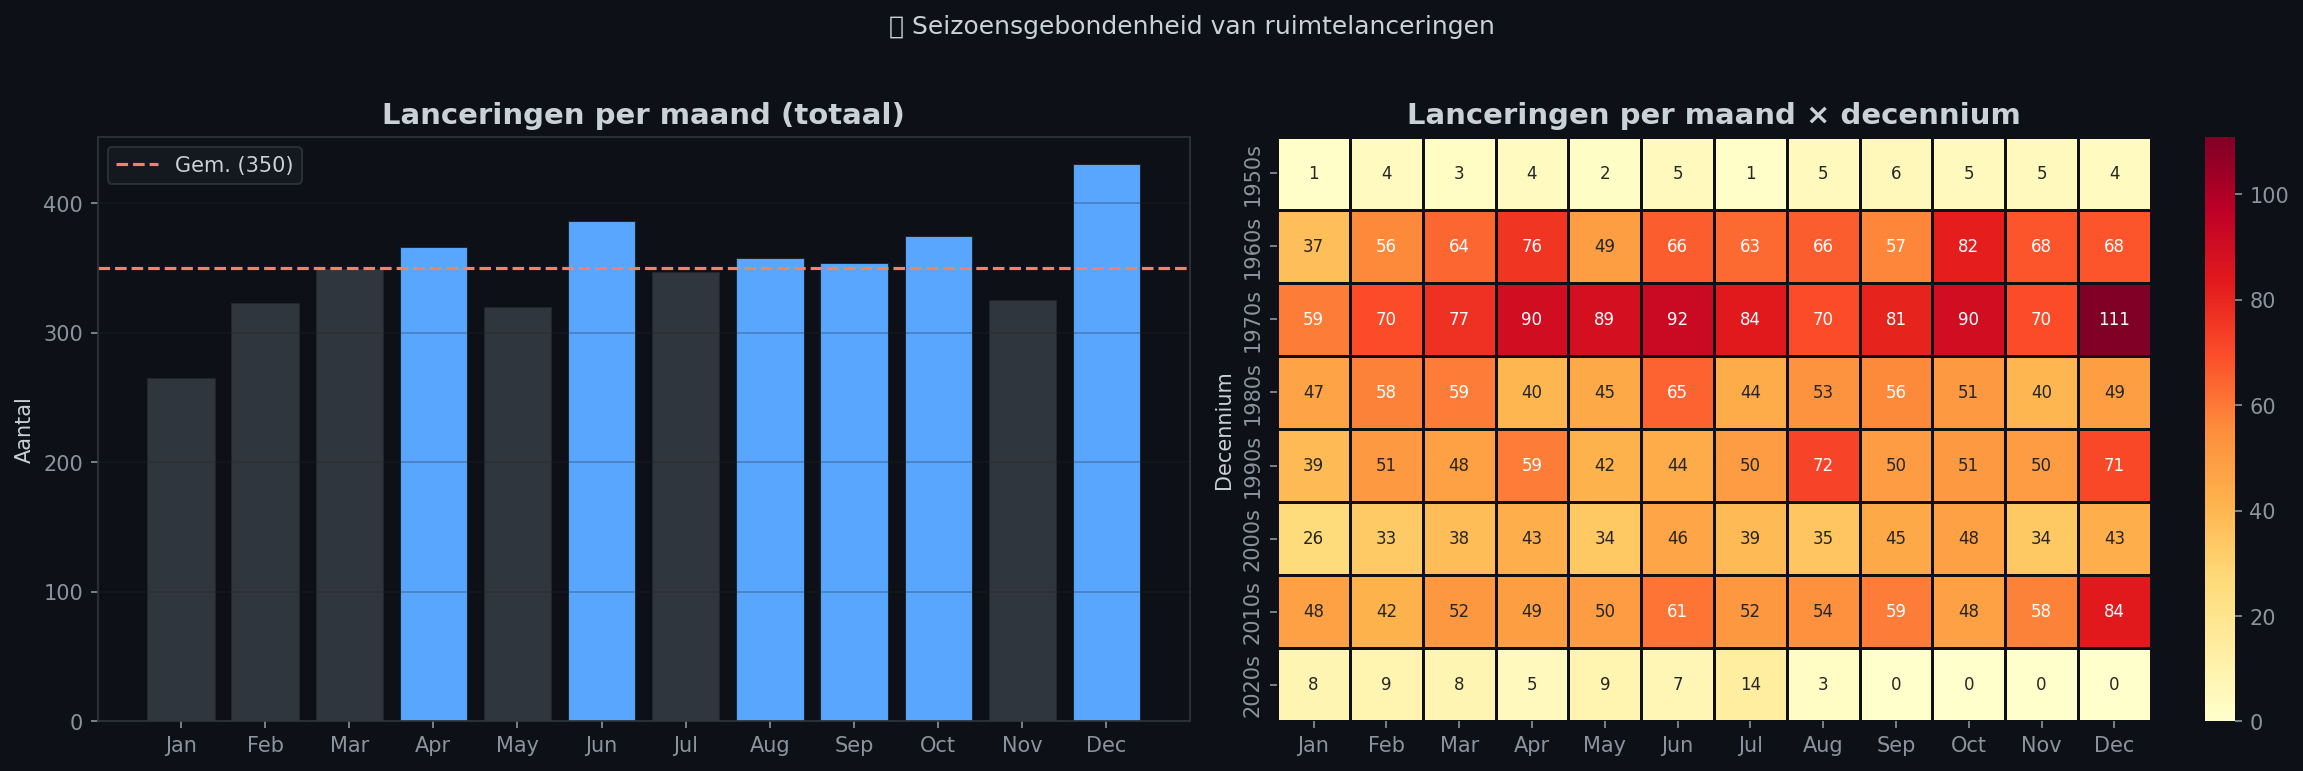

## 4. 🛡 Zijn ruimtemissies veiliger geworden?

In de vroege jaren 60 mislukten 3 op de 10 lanceringen. Nu is de succesratio structureel boven de 95%. De leercurve en betere technologie zijn duidelijk zichtbaar.

In [ ]:
ys = (df.groupby('Year')
        .agg(Total=('Success','count'), Successes=('Success','sum'))
        .reset_index())
ys['Rate'] = ys['Successes'] / ys['Total'] * 100
ys['Roll'] = ys['Rate'].rolling(5, center=True).mean()
ds = df.groupby('Decade').agg(Rate=('Success','mean')).reset_index()
ds['Rate'] *= 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={'height_ratios': [3, 1]})
ax1.scatter(ys['Year'], ys['Rate'], color=ACCENT, alpha=0.4, s=30, zorder=4)
ax1.plot(ys['Year'], ys['Roll'], color=ACCENT3, linewidth=2.5,
         label='5-jaars gemiddelde', zorder=5)
ax1.axhline(90, color=ACCENT2, linewidth=1, linestyle='--',
            alpha=0.6, label='90% drempel')
ax1.fill_between(ys['Year'], ys['Roll'].fillna(0), alpha=0.1, color=ACCENT3)
ax1.set_title('🛡 Slagingspercentage van ruimtemissies (1957–2020)', pad=15)
ax1.set_ylabel('Slagingspercentage (%)'); ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3)
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')

cc = [ACCENT3 if r>=90 else ACCENT4 if r>=80 else ACCENT2 for r in ds['Rate']]
bars = ax2.bar(ds['Decade'], ds['Rate'], color=cc, edgecolor='#21262d', linewidth=0.5)
ax2.set_ylabel('Succes %'); ax2.set_ylim(60, 105); ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ds['Rate']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

print("Slagingspercentage per decennium:")
print(ds.to_string(index=False))


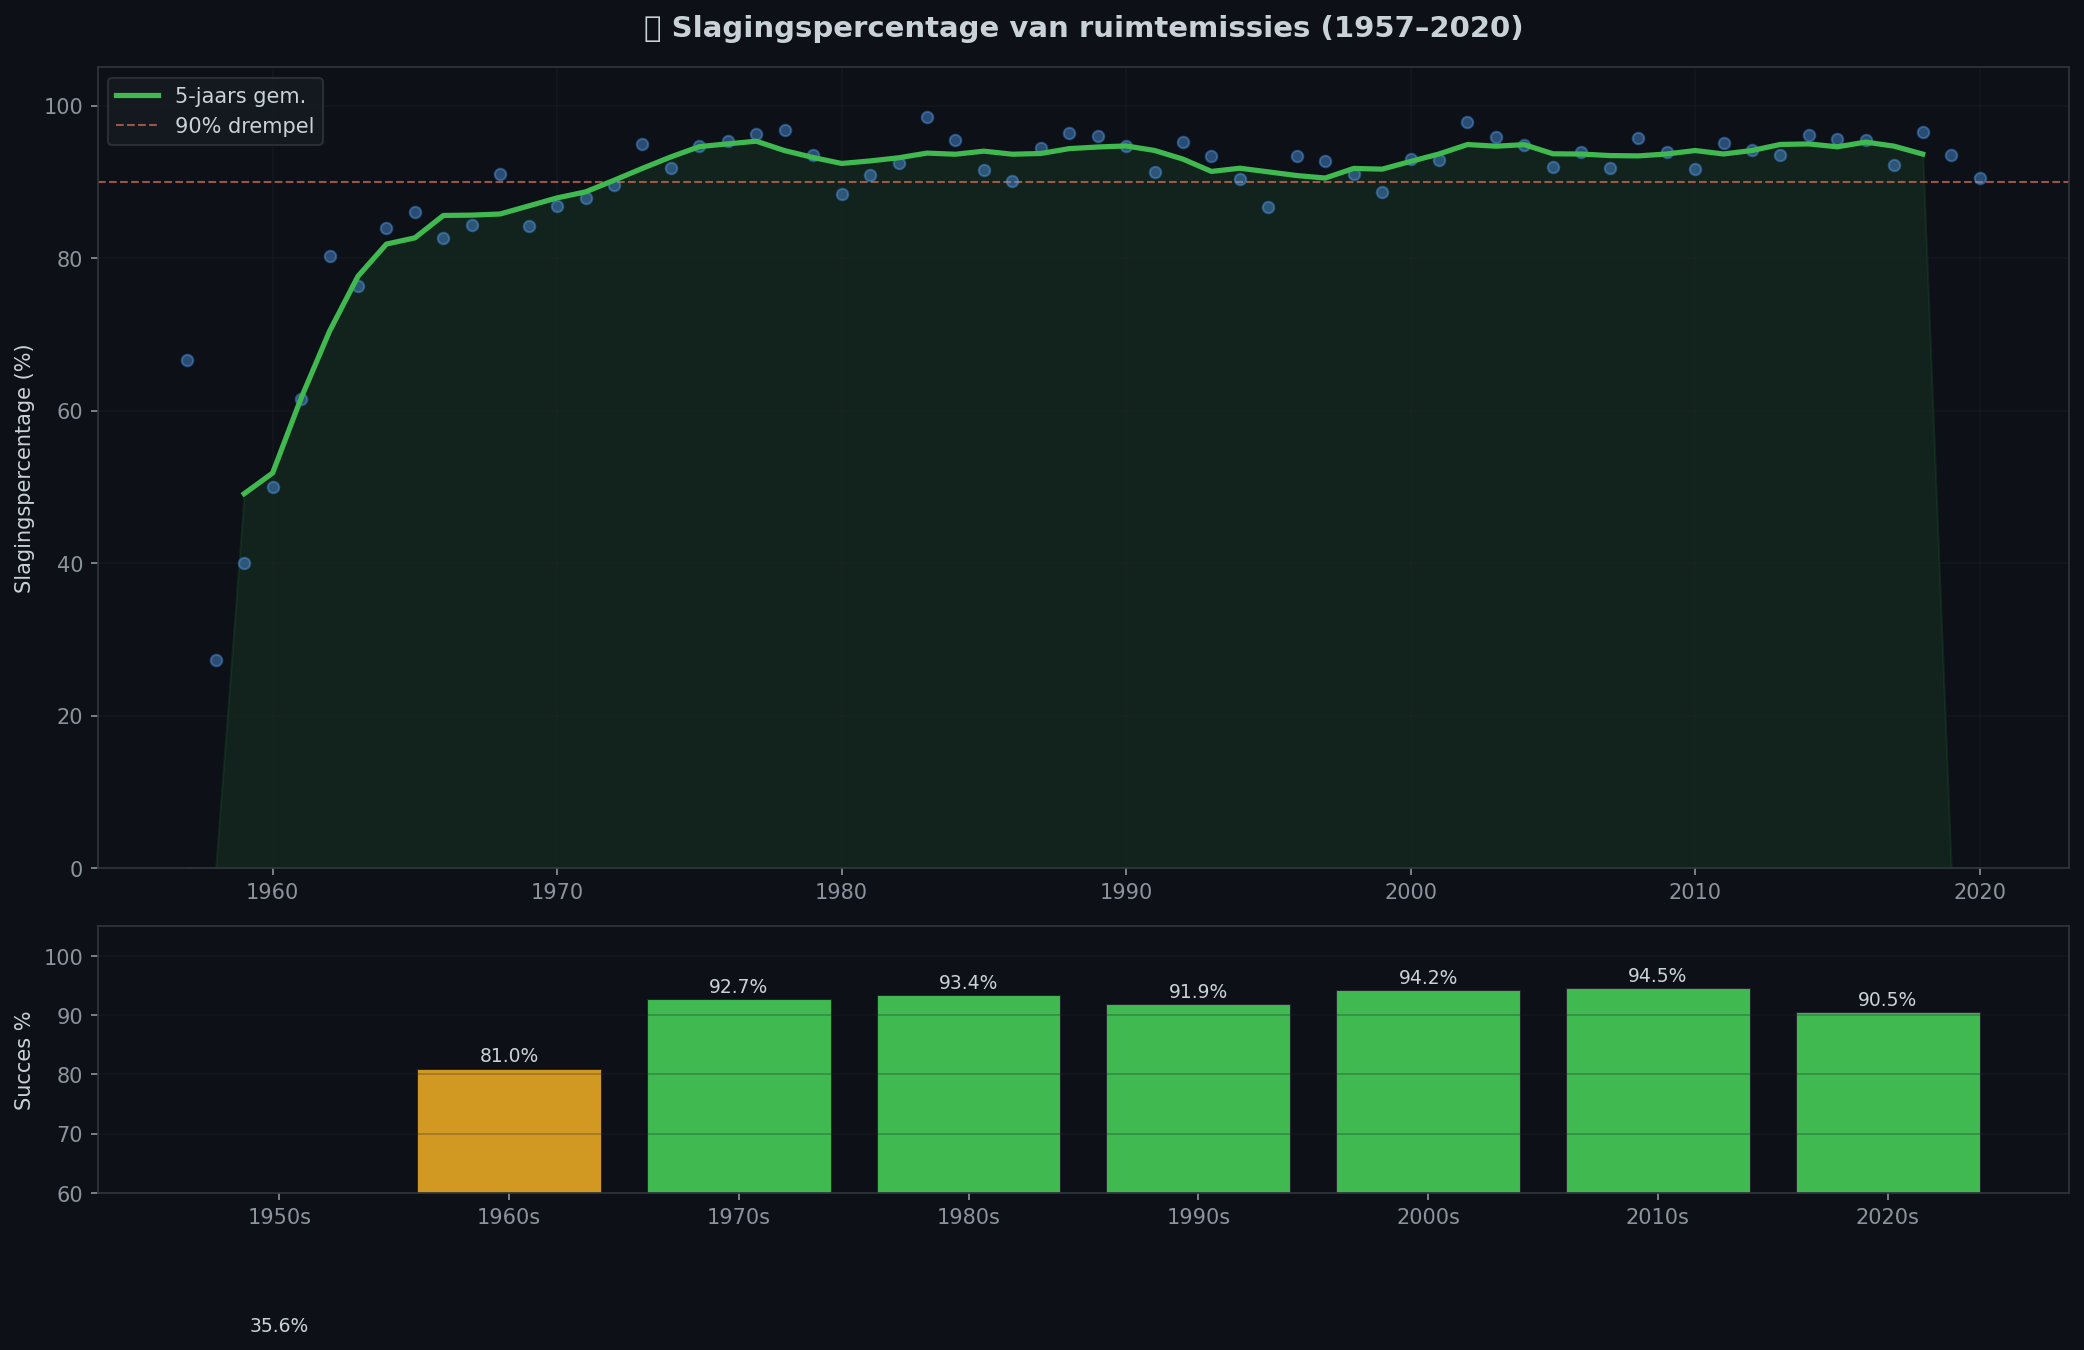

## 5. 🌍 Welke landen domineren? (Choropleth)

Rusland (voormalige Sovjet-Unie) staat ver bovenaan met 2.096 lanceringen, gevolgd door de VS (1.344) en China (268, maar groeiend).

In [ ]:
country_launches = (df[df['Country'] != 'Pacific Ocean']
                    ['Country'].value_counts().reset_index())
country_launches.columns = ['Country', 'Launches']

fig = px.choropleth(
    country_launches,
    locations='Country', locationmode='country names',
    color='Launches', color_continuous_scale='Plasma',
    title='🌍 Totaal aantal ruimtelanceringen per land (1957–2020)',
    labels={'Launches': 'Lanceringen'},
)
fig.update_layout(
    template='plotly_dark', paper_bgcolor='#0d1117',
    title_font_size=16,
    geo=dict(bgcolor='#0d1117', lakecolor='#0d1117',
             landcolor='#21262d', showframe=False),
)
fig.show()
print(country_launches.head(10).to_string(index=False))


## 6. 🏆 Slagingspercentage per organisatie

Alleen organisaties met ≥ 20 lanceringen. SpaceX, Arianespace en ISRO scoren het beste. De vroege VS-organisaties (General Dynamics, Martin Marietta) hadden in de jaren 60 nog lagere succesratio's.

In [ ]:
from matplotlib.patches import Patch

os2 = (df.groupby('Organisation')
         .agg(Total=('Success','count'), Successes=('Success','sum'))
         .reset_index())
os2['Rate'] = os2['Successes'] / os2['Total'] * 100
os2 = os2[os2['Total'] >= 20].sort_values('Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
co = [ACCENT3 if r>=95 else ACCENT if r>=85 else ACCENT4 if r>=70 else ACCENT2
      for r in os2['Rate']]
bars = ax.barh(os2['Organisation'], os2['Rate'], color=co,
               edgecolor='#21262d', linewidth=0.5, height=0.7)
ax.axvline(90, color='#ffffff', linewidth=1, linestyle='--', alpha=0.3)
for bar, (_, row) in zip(bars, os2.iterrows()):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{row["Rate"]:.1f}%  (n={row["Total"]:.0f})',
            va='center', fontsize=8.5)
ax.set_xlim(0, 118); ax.set_xlabel('Slagingspercentage (%)')
ax.set_title('🏆 Slagingspercentage per organisatie (min. 20 lanceringen)', pad=15)
ax.grid(True, alpha=0.3, axis='x')
leg = [Patch(facecolor=ACCENT3, label='≥ 95%'), Patch(facecolor=ACCENT, label='85–95%'),
       Patch(facecolor=ACCENT4, label='70–85%'), Patch(facecolor=ACCENT2, label='< 70%')]
ax.legend(handles=leg, facecolor='#161b22', edgecolor='#30363d',
          labelcolor='#c9d1d9', loc='lower right')
plt.tight_layout(); plt.show()


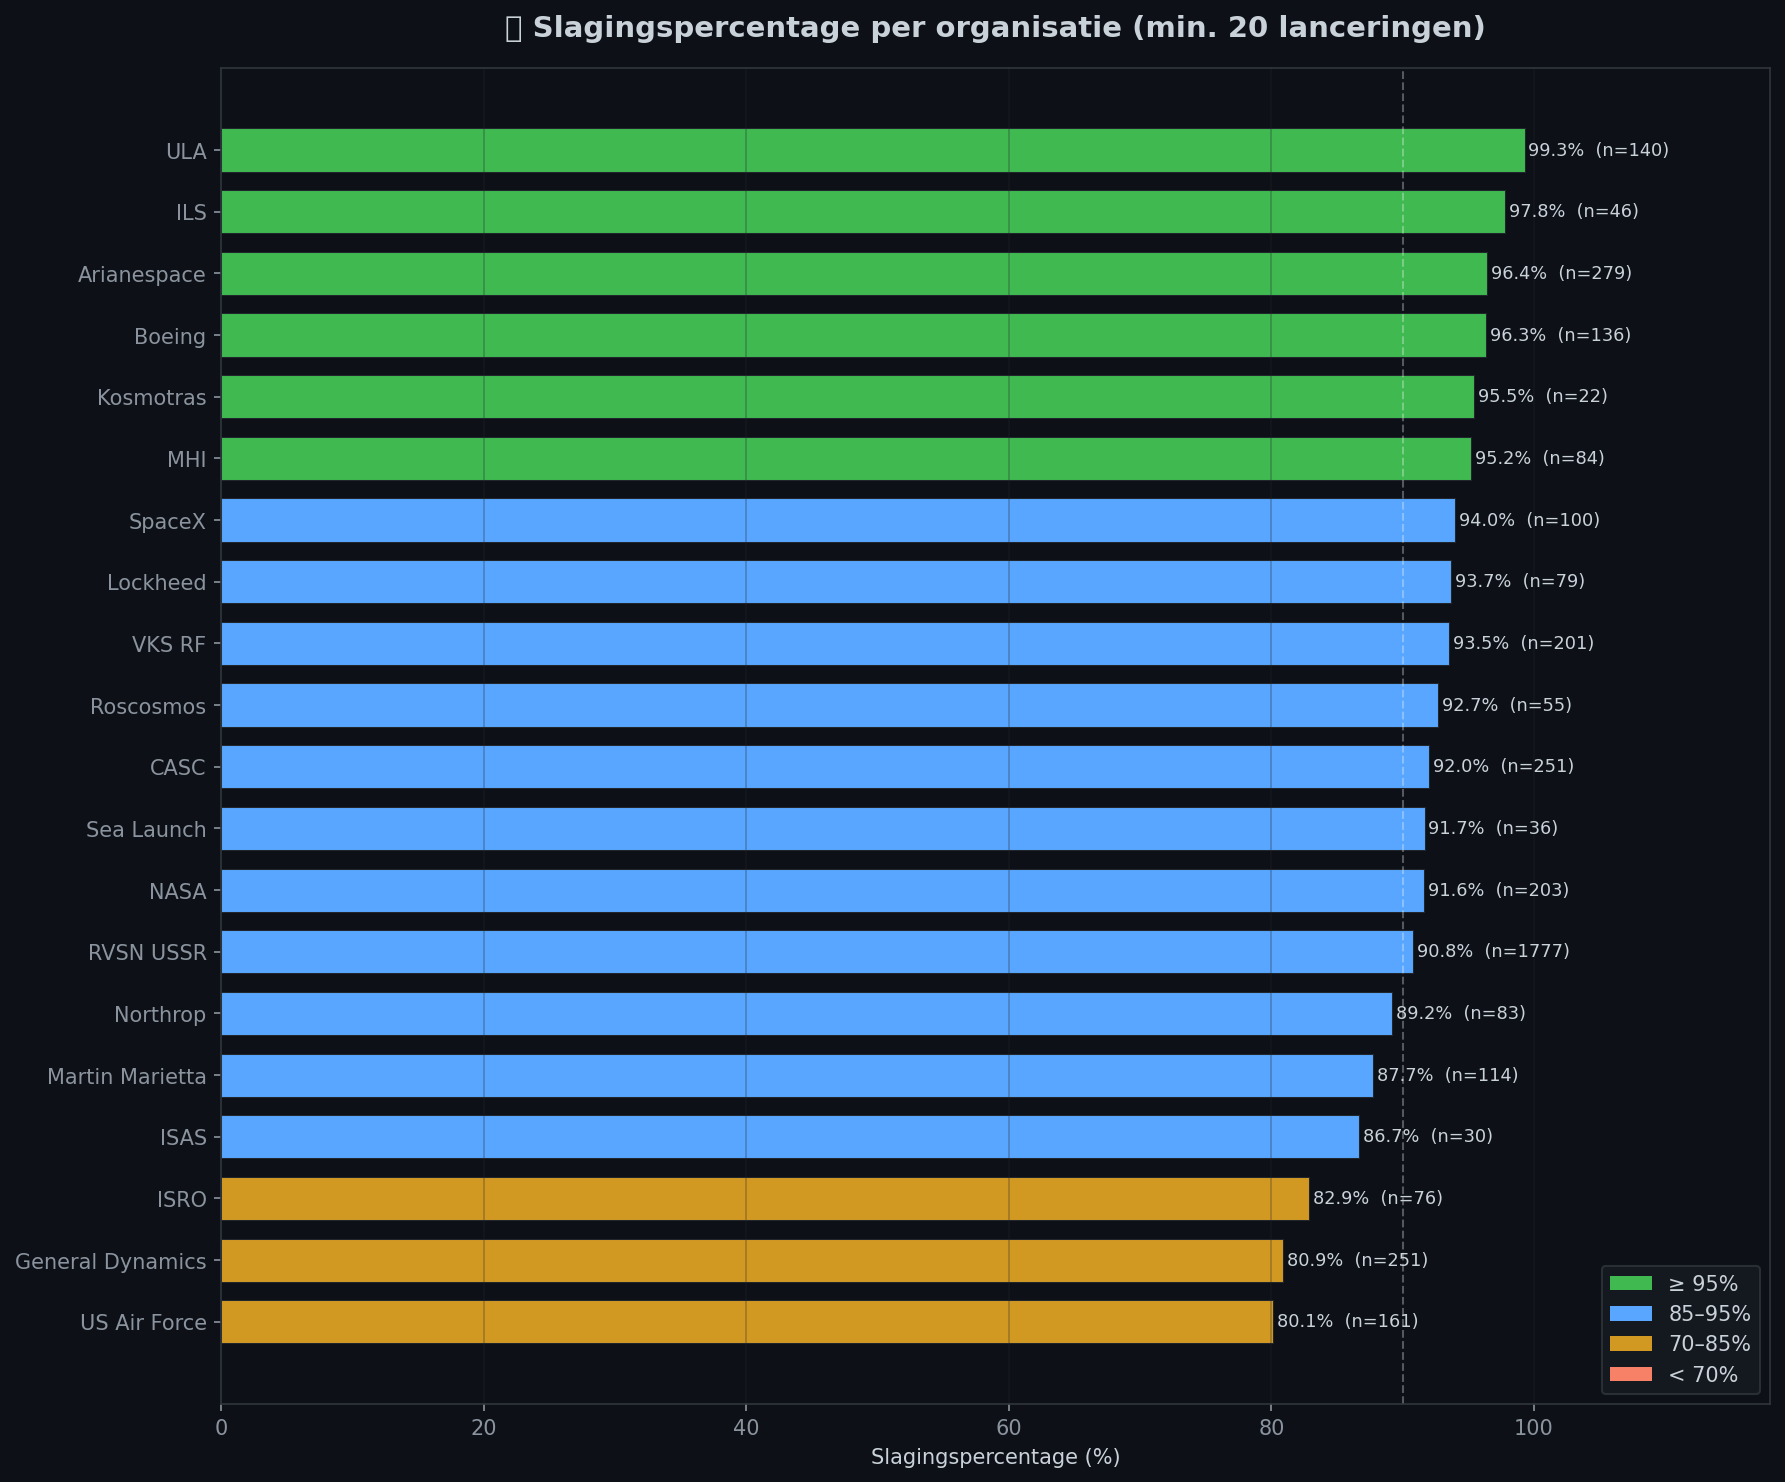

## 7. 🔧 Actieve vs gepensioneerde raketten

De Sovjet-Unie/Rusland heeft verreweg de meeste raketversies gepensioneerd — logisch gezien de 60+ jaar lanceringen. SpaceX heeft relatief weinig maar zeer actieve raketfamilies.

In [ ]:
rs = (df.groupby(['Organisation','Rocket_Status'])
        .size().unstack(fill_value=0).reset_index())
rs.columns.name = None
rs['Total'] = (rs.get('StatusActive', 0) + rs.get('StatusRetired', 0))
top12 = rs.nlargest(12, 'Total')

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top12)); w = 0.38
act = top12['StatusActive'].values if 'StatusActive' in top12 else np.zeros(len(top12))
ret = top12['StatusRetired'].values if 'StatusRetired' in top12 else np.zeros(len(top12))
ax.bar(x-w/2, act, width=w, label='Actief',
       color=ACCENT3, edgecolor='#21262d', linewidth=0.5)
ax.bar(x+w/2, ret, width=w, label='Gepensioneerd',
       color=ACCENT2, edgecolor='#21262d', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(top12['Organisation'], rotation=35, ha='right')
ax.set_ylabel('Raketversies')
ax.set_title('🔧 Actieve vs gepensioneerde raketversies (top 12)', pad=15)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


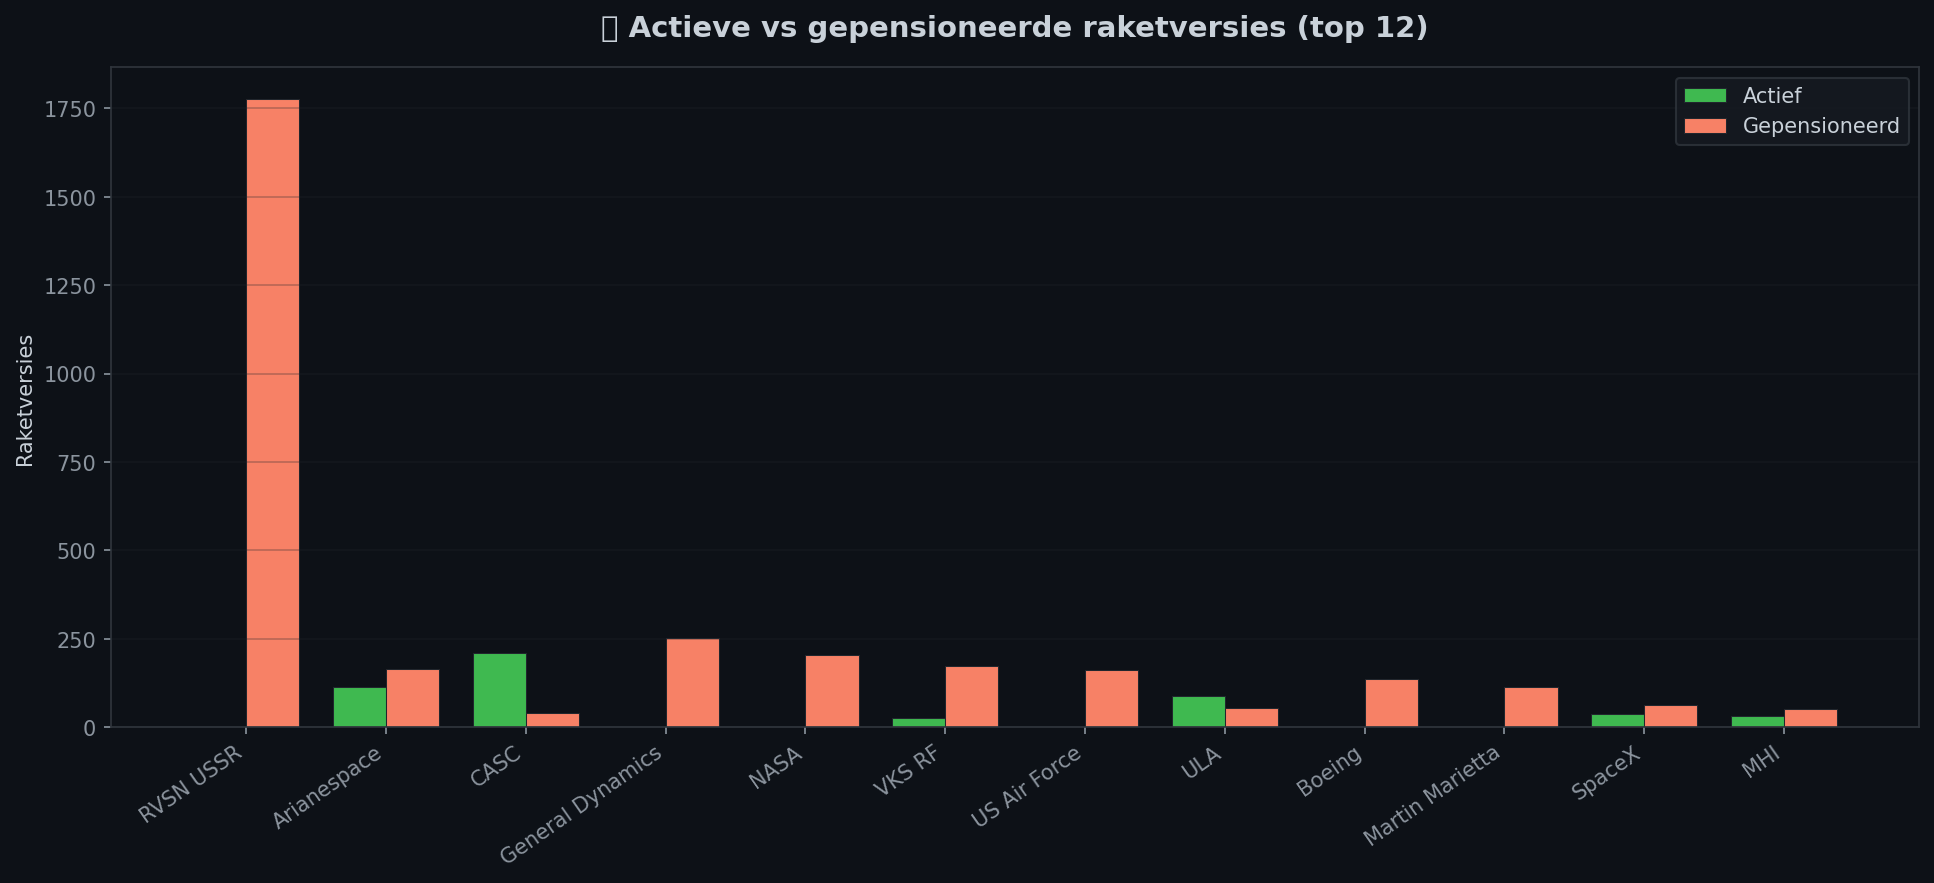

## 8. ☀️ Verdeling per land en organisatie (Sunburst)

Een interactief sunburst-diagram toont hoe lanceringen verdeeld zijn over landen en hun organisaties.

In [ ]:
top_c = df['Country'].value_counts().index[:8].tolist()
sun_df = df[df['Country'].isin(top_c)].copy()
org_country = (sun_df.groupby(['Country','Organisation'])
                      .size().reset_index(name='Count'))
org_country = (org_country.groupby('Country', group_keys=False)
                           .apply(lambda x: x.nlargest(5,'Count'))
                           .reset_index(drop=True))

fig = px.sunburst(
    org_country, path=['Country','Organisation'], values='Count',
    color='Count', color_continuous_scale='Blues',
    title='☀️ Ruimtelanceringen per land en organisatie (top 5 per land)',
)
fig.update_layout(template='plotly_dark', paper_bgcolor='#0d1117',
                  title_font_size=16, height=650)
fig.update_traces(textinfo='label+percent entry')
fig.show()


## 📌 Conclusies

| Vraag | Bevinding |
|---|---|
| **Meeste lanceringen** | Rusland: 2.096 (piek 1982: 128 lanceringen!). VS: 1.344. China groeit snel. |
| **Kosten** | Mediaan $40–170M. Recente commercialisering (SpaceX) drukt prijzen. |
| **Drukste maand** | December is het drukst historisch gezien; januari is het rustigst. |
| **Veiligheid** | Van ~70% succes (1957–60) naar >95% structureel na 2000. |
| **Beste organisaties** | SpaceX, ISRO, Arianespace scoren ≥ 95% succesratio. |
| **Landen** | Rusland #1, VS #2, China snel stijgend. Slechts 8 landen met >10 lanceringen. |

> **Grote conclusie:** De ruimtevaart is dramatisch veiliger, goedkoper en toegankelijker geworden.  
> De commercialisering na 2000 — SpaceX voorop — heeft de lanceringsfrequentie van de VS nieuw leven ingeblazen.
